# Options Strategy Recommendation and Optimisation System
## Notebook 6 - Experiments and Evaluation

This notebook evaluates the complete reasoning and optimisation pipeline created in Notebooks 1-5. It audits upstream quality, exercises rule branches with controlled scenarios, compares recommendation methods, stress-tests current candidates with historical underlying returns, and tests GA stability and fitness-weight sensitivity.

## Evaluation boundary

This notebook **does not claim a full historical options backtest**. Yahoo Finance exposes current option chains and limited price history for some active contracts, but it does not provide a dependable archive of expired chains with contemporaneous bid/ask quotes.

The evidence used here is therefore:

- current-chain payoffs and Monte Carlo metrics from Notebook 4;
- cost-adjusted optimisation results from Notebook 5;
- historical-underlying return stress simulation using today's candidate definitions and premiums;
- controlled rule scenarios and branch coverage;
- repeated-seed, exhaustive-oracle, transaction-cost, and fitness-weight experiments;
- optional inspection of an active contract history CSV when supplied.

These results evaluate the MVP's consistency and decision quality, not future profitability.

## 1. Environment setup

If required, install packages once with: `pip install pandas numpy matplotlib`.

In [5]:
from __future__ import annotations

import itertools
import json
import math
import re
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__} | numpy: {np.__version__}")

Python: 3.9.23 | pandas: 2.3.2 | numpy: 1.26.4


## 2. Configuration and required upstream outputs

Use the same ticker and bullish/bearish outlook as Notebooks 1-5. The optional active-contract file is not required for the evaluation to pass.

In [7]:
TICKER = "CRM"
OUTLOOK = "bullish"  # allowed: bullish, bearish


In [8]:
NOTEBOOK1_ROOT = Path("outputs/notebook_01")
NOTEBOOK2_ROOT = Path("outputs/notebook_02")
NOTEBOOK3_ROOT = Path("outputs/notebook_03")
NOTEBOOK4_ROOT = Path("outputs/notebook_04")
NOTEBOOK5_ROOT = Path("outputs/notebook_05")
NOTEBOOK6_ROOT = Path("outputs/notebook_06")

RULE_RANDOM_SEED = 42
RANDOM_CHROMOSOME_TRIALS = 5_000
HISTORICAL_STRESS_PATHS = 8_000
HISTORICAL_STRESS_RANDOM_CANDIDATES = 100
SELECTOR_TIMING_REPEATS = 250
TOP_K_SENSITIVITY = 10

def validate_settings(ticker: str, outlook: str) -> tuple[str, str]:
    ticker = ticker.strip().upper().replace(".", "-")
    outlook = outlook.strip().lower()
    if not ticker or not re.fullmatch(r"[A-Z0-9^=-]{1,15}", ticker):
        raise ValueError("Ticker is empty or contains unsupported characters.")
    if outlook not in {"bullish", "bearish"}:
        raise ValueError("OUTLOOK must be either 'bullish' or 'bearish'.")
    return ticker, outlook

ticker, outlook = validate_settings(TICKER, OUTLOOK)
run_name = f"{ticker}_{outlook}"
NOTEBOOK1_DIR = NOTEBOOK1_ROOT / ticker
NOTEBOOK2_DIR = NOTEBOOK2_ROOT / ticker
NOTEBOOK3_DIR = NOTEBOOK3_ROOT / ticker / outlook
NOTEBOOK4_DIR = NOTEBOOK4_ROOT / ticker / outlook
NOTEBOOK5_DIR = NOTEBOOK5_ROOT / ticker / outlook
OUTPUT_DIR = NOTEBOOK6_ROOT / ticker / outlook
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ACTIVE_CONTRACT_HISTORY_CSV = NOTEBOOK1_DIR / "active_contract_history.csv"

input_paths = {
    "history_features": NOTEBOOK1_DIR / "history_features.csv",
    "notebook1_quality": NOTEBOOK1_DIR / "quality_report.csv",
    "feature_snapshot": NOTEBOOK2_DIR / "feature_snapshot.json",
    "notebook2_quality": NOTEBOOK2_DIR / "feature_quality_report.csv",
    "ranked_strategies": NOTEBOOK3_DIR / "ranked_strategy_families.csv",
    "reasoning_trace": NOTEBOOK3_DIR / "reasoning_trace.json",
    "notebook3_quality": NOTEBOOK3_DIR / "reasoning_quality_report.csv",
    "candidate_universe": NOTEBOOK4_DIR / "candidate_universe.csv",
    "notebook4_quality": NOTEBOOK4_DIR / "payoff_quality_report.csv",
    "ranked_recommendations": NOTEBOOK5_DIR / "ga_ranked_recommendations.csv",
    "best_strategy": NOTEBOOK5_DIR / "ga_best_strategy.json",
    "convergence_history": NOTEBOOK5_DIR / "ga_convergence_history.csv",
    "ga_run_summary": NOTEBOOK5_DIR / "ga_run_summary.csv",
    "ga_benchmark": NOTEBOOK5_DIR / "ga_benchmark.csv",
    "cost_sensitivity": NOTEBOOK5_DIR / "ga_cost_sensitivity.csv",
    "notebook5_quality": NOTEBOOK5_DIR / "ga_quality_report.csv",
    "optimisation_snapshot": NOTEBOOK5_DIR / "ga_optimisation_snapshot.json",
}
input_paths


{'history_features': WindowsPath('outputs/notebook_01/CRM/history_features.csv'),
 'notebook1_quality': WindowsPath('outputs/notebook_01/CRM/quality_report.csv'),
 'feature_snapshot': WindowsPath('outputs/notebook_02/CRM/feature_snapshot.json'),
 'notebook2_quality': WindowsPath('outputs/notebook_02/CRM/feature_quality_report.csv'),
 'ranked_strategies': WindowsPath('outputs/notebook_03/CRM/bullish/ranked_strategy_families.csv'),
 'reasoning_trace': WindowsPath('outputs/notebook_03/CRM/bullish/reasoning_trace.json'),
 'notebook3_quality': WindowsPath('outputs/notebook_03/CRM/bullish/reasoning_quality_report.csv'),
 'candidate_universe': WindowsPath('outputs/notebook_04/CRM/bullish/candidate_universe.csv'),
 'notebook4_quality': WindowsPath('outputs/notebook_04/CRM/bullish/payoff_quality_report.csv'),
 'ranked_recommendations': WindowsPath('outputs/notebook_05/CRM/bullish/ga_ranked_recommendations.csv'),
 'best_strategy': WindowsPath('outputs/notebook_05/CRM/bullish/ga_best_strategy.jso

In [9]:
missing_files = [str(path) for path in input_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Required upstream outputs were not found. Run Notebooks 1-5 with the same ticker/outlook first. Missing: "
        + ", ".join(missing_files)
    )

history_features = pd.read_csv(input_paths["history_features"])
ranked_strategies = pd.read_csv(input_paths["ranked_strategies"])
candidate_universe = pd.read_csv(input_paths["candidate_universe"])
ranked_recommendations = pd.read_csv(input_paths["ranked_recommendations"])
convergence_history = pd.read_csv(input_paths["convergence_history"])
ga_run_summary = pd.read_csv(input_paths["ga_run_summary"])
ga_benchmark = pd.read_csv(input_paths["ga_benchmark"])
cost_sensitivity = pd.read_csv(input_paths["cost_sensitivity"])

with input_paths["feature_snapshot"].open("r", encoding="utf-8") as file:
    feature_snapshot = json.load(file)
with input_paths["reasoning_trace"].open("r", encoding="utf-8") as file:
    reasoning_trace = json.load(file)
with input_paths["best_strategy"].open("r", encoding="utf-8") as file:
    best_strategy = json.load(file)
with input_paths["optimisation_snapshot"].open("r", encoding="utf-8") as file:
    optimisation_snapshot = json.load(file)

expected_request = {"ticker": ticker, "outlook": outlook}
if feature_snapshot.get("request") != {"ticker": ticker}:
    raise ValueError("Notebook 2 snapshot does not match the configured ticker.")
pair_request_records = [
    reasoning_trace.get("request"), best_strategy.get("request"),
    optimisation_snapshot.get("request"),
]
if any(record != expected_request for record in pair_request_records):
    raise ValueError("At least one directional upstream JSON file does not match the configured ticker/outlook.")
if any(frame.empty for frame in [history_features, ranked_strategies, candidate_universe, ranked_recommendations, convergence_history, ga_run_summary]):
    raise ValueError("At least one required upstream dataset is empty.")

numeric_recommendation_columns = [
    "strategy_rank", "reasoning_score", "strategy_index", "expiry_index", "long_strike_index",
    "short_strike_index", "dte", "long_strike", "short_strike", "long_entry_price",
    "short_entry_price", "entry_cashflow_per_share", "max_loss", "liquidity_score",
    "probability_of_profit", "expected_profit", "p05_profit", "p95_profit",
    "payoff_engine_rank", "estimated_transaction_cost", "adjusted_expected_profit",
    "adjusted_max_loss", "net_expected_return_on_risk", "fitness_score", "fitness_rank",
]
for column in numeric_recommendation_columns:
    if column in ranked_recommendations.columns:
        ranked_recommendations[column] = pd.to_numeric(ranked_recommendations[column], errors="coerce")

print(
    f"Loaded {len(history_features):,} underlying-history rows, {len(candidate_universe):,} feasible candidates, "
    f"and {len(ranked_recommendations):,} ranked recommendations."
)

Loaded 501 underlying-history rows, 64 feasible candidates, and 64 ranked recommendations.


## 3. End-to-end quality audit

All upstream quality reports are combined so the final experiment records whether data, features, reasoning, payoffs, and optimisation passed their own gates.

,stage,checks,passed,pass_rate
0,Notebook 1 - Data,10,10,1.0000
1,Notebook 2 - Features,9,9,1.0000
2,Notebook 3 - Reasoning,10,10,1.0000
3,Notebook 4 - Payoffs,10,10,1.0000
4,Notebook 5 - Optimisation,14,14,1.0000


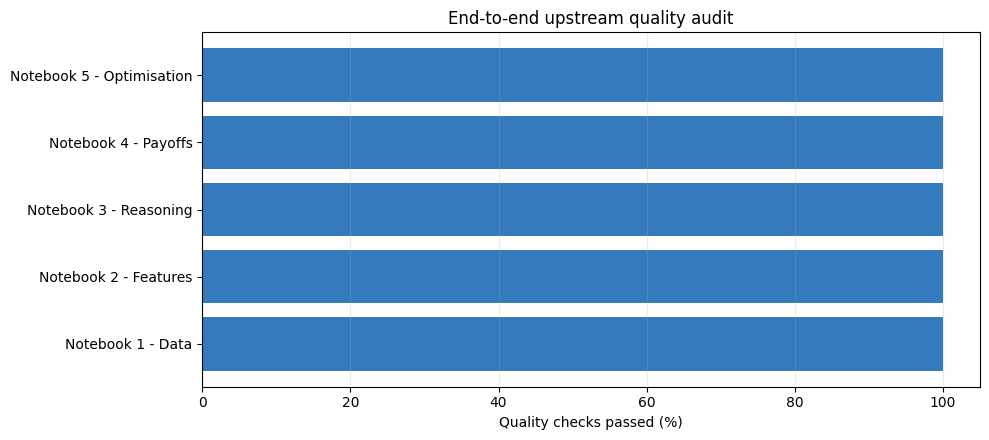

In [11]:
def normalise_passed(values: pd.Series) -> pd.Series:
    return values.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})

quality_sources = [
    ("Notebook 1 - Data", input_paths["notebook1_quality"]),
    ("Notebook 2 - Features", input_paths["notebook2_quality"]),
    ("Notebook 3 - Reasoning", input_paths["notebook3_quality"]),
    ("Notebook 4 - Payoffs", input_paths["notebook4_quality"]),
    ("Notebook 5 - Optimisation", input_paths["notebook5_quality"]),
]

audit_frames: list[pd.DataFrame] = []
for stage, path in quality_sources:
    report = pd.read_csv(path)
    if not {"check", "passed"}.issubset(report.columns):
        raise KeyError(f"Quality report {path} must contain 'check' and 'passed'.")
    report = report[["check", "passed"]].copy()
    report["passed"] = normalise_passed(report["passed"])
    report.insert(0, "stage", stage)
    audit_frames.append(report)

pipeline_quality_audit = pd.concat(audit_frames, ignore_index=True)
pipeline_quality_summary = pipeline_quality_audit.groupby("stage", as_index=False).agg(
    checks=("check", "count"), passed=("passed", "sum")
)
pipeline_quality_summary["pass_rate"] = pipeline_quality_summary["passed"] / pipeline_quality_summary["checks"]
display(pipeline_quality_summary)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(pipeline_quality_summary["stage"], pipeline_quality_summary["pass_rate"] * 100, color="#357ABD")
ax.set_xlim(0, 105)
ax.set_xlabel("Quality checks passed (%)")
ax.set_title("End-to-end upstream quality audit")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Controlled rule scenarios and branch coverage

The following grid covers both directions, low/high implied-volatility conditions, all three trend-alignment states, four liquidity branches, and sufficient/insufficient two-leg contract availability. This yields 96 deterministic scenarios.

In [13]:
STRATEGY_METADATA = pd.DataFrame([
    ("bull_call_spread", "Bull Call Spread", "bullish", "debit", 2),
    ("bull_put_spread", "Bull Put Spread", "bullish", "credit", 2),
    ("long_call", "Long Call", "bullish", "debit", 1),
    ("bear_put_spread", "Bear Put Spread", "bearish", "debit", 2),
    ("bear_call_spread", "Bear Call Spread", "bearish", "credit", 2),
    ("long_put", "Long Put", "bearish", "debit", 1),
], columns=["strategy_id", "name", "direction", "premium_style", "leg_count"])

BASE_SCORES = {
    ("bullish", False): {"bull_call_spread": 95, "long_call": 85, "bull_put_spread": 55},
    ("bullish", True): {"bull_put_spread": 100, "bull_call_spread": 75, "long_call": 45},
    ("bearish", False): {"bear_put_spread": 95, "long_put": 85, "bear_call_spread": 55},
    ("bearish", True): {"bear_call_spread": 100, "bear_put_spread": 75, "long_put": 45},
}

def replay_reasoning_rules(
    scenario_outlook: str,
    high_iv: bool,
    alignment: str,
    liquidity: float,
    candidate_contract_count: int,
) -> pd.DataFrame:
    direction_set = STRATEGY_METADATA.loc[STRATEGY_METADATA["direction"].eq(scenario_outlook)].copy()
    rows: list[dict[str, Any]] = []
    for strategy in direction_set.itertuples(index=False):
        score = float(BASE_SCORES[(scenario_outlook, high_iv)][strategy.strategy_id])
        score += 10 if alignment == "aligned" else -20 if alignment == "conflicting" else 0
        score += 10 if liquidity >= 75 else 5 if liquidity >= 50 else -15 if liquidity < 25 else 0
        availability_penalty = strategy.leg_count == 2 and candidate_contract_count < 4
        if availability_penalty:
            score -= 20
        rows.append({
            "strategy_id": strategy.strategy_id,
            "name": strategy.name,
            "direction": strategy.direction,
            "premium_style": strategy.premium_style,
            "leg_count": strategy.leg_count,
            "availability_penalty": availability_penalty,
            "reasoning_score": float(np.clip(score, 0, 120)),
        })
    return pd.DataFrame(rows).sort_values(["reasoning_score", "name"], ascending=[False, True]).reset_index(drop=True)

scenario_rows: list[dict[str, Any]] = []
scenario_id = 0
for scenario_outlook, high_iv, alignment, liquidity, contract_count in itertools.product(
    ["bullish", "bearish"], [False, True], ["aligned", "neutral", "conflicting"],
    [85.0, 60.0, 35.0, 15.0], [3, 8],
):
    scenario_id += 1
    ranking = replay_reasoning_rules(scenario_outlook, high_iv, alignment, liquidity, contract_count)
    top = ranking.iloc[0]
    expected_premium_style = "credit" if high_iv else "debit"
    scenario_rows.append({
        "scenario_id": scenario_id,
        "outlook": scenario_outlook,
        "high_iv": high_iv,
        "alignment": alignment,
        "liquidity": liquidity,
        "candidate_contract_count": contract_count,
        "top_strategy": top["strategy_id"],
        "top_reasoning_score": top["reasoning_score"],
        "direction_pass": top["direction"] == scenario_outlook,
        "volatility_preference_pass": top["premium_style"] == expected_premium_style,
        "scores_bounded_pass": bool(ranking["reasoning_score"].between(0, 120).all()),
    })

rule_scenario_results = pd.DataFrame(scenario_rows)
rule_scenario_results["scenario_passed"] = rule_scenario_results[
    ["direction_pass", "volatility_preference_pass", "scores_bounded_pass"]
].all(axis=1)
print(f"Scenario pass rate: {rule_scenario_results['scenario_passed'].mean():.1%} across {len(rule_scenario_results)} scenarios")
display(rule_scenario_results.head(12))

Scenario pass rate: 100.0% across 96 scenarios


,scenario_id,outlook,high_iv,alignment,liquidity,candidate_contract_count,top_strategy,top_reasoning_score,direction_pass,volatility_preference_pass,scores_bounded_pass,scenario_passed
0,1,bullish,False,aligned,85.0000,3,long_call,105.0000,True,True,True,True
1,2,bullish,False,aligned,85.0000,8,bull_call_spread,115.0000,True,True,True,True
2,3,bullish,False,aligned,60.0000,3,long_call,100.0000,True,True,True,True
3,4,bullish,False,aligned,60.0000,8,bull_call_spread,110.0000,True,True,True,True
4,5,bullish,False,aligned,35.0000,3,long_call,95.0000,True,True,True,True
5,6,bullish,False,aligned,35.0000,8,bull_call_spread,105.0000,True,True,True,True
6,7,bullish,False,aligned,15.0000,3,long_call,80.0000,True,True,True,True
7,8,bullish,False,aligned,15.0000,8,bull_call_spread,90.0000,True,True,True,True
8,9,bullish,False,neutral,85.0000,3,long_call,95.0000,True,True,True,True
9,10,bullish,False,neutral,85.0000,8,bull_call_spread,105.0000,True,True,True,True


In [14]:
branch_conditions = {
    "bullish direction": rule_scenario_results["outlook"].eq("bullish"),
    "bearish direction": rule_scenario_results["outlook"].eq("bearish"),
    "low/balanced IV": ~rule_scenario_results["high_iv"],
    "elevated/high IV": rule_scenario_results["high_iv"],
    "aligned trend": rule_scenario_results["alignment"].eq("aligned"),
    "neutral trend": rule_scenario_results["alignment"].eq("neutral"),
    "conflicting trend": rule_scenario_results["alignment"].eq("conflicting"),
    "liquidity >= 75": rule_scenario_results["liquidity"].ge(75),
    "liquidity 50-74": rule_scenario_results["liquidity"].between(50, 74.999),
    "liquidity 25-49": rule_scenario_results["liquidity"].between(25, 49.999),
    "liquidity < 25": rule_scenario_results["liquidity"].lt(25),
    "two-leg availability penalty": rule_scenario_results["candidate_contract_count"].lt(4),
    "sufficient contract availability": rule_scenario_results["candidate_contract_count"].ge(4),
}
rule_branch_coverage = pd.DataFrame([
    {"rule_branch": name, "scenario_count": int(mask.sum()), "covered": bool(mask.any())}
    for name, mask in branch_conditions.items()
])
display(rule_branch_coverage)

selected_expiry = reasoning_trace["selected_expiry"]
current_high_iv = str(selected_expiry["volatility_regime"]) in {"elevated_iv", "high_iv"}
current_alignment = str(ranked_strategies.sort_values("rank").iloc[0]["outlook_alignment"])
current_replay = replay_reasoning_rules(
    outlook,
    current_high_iv,
    current_alignment,
    float(selected_expiry["median_liquidity_score"]),
    int(selected_expiry["candidate_contract_count"]),
)
actual_top_strategy = str(ranked_strategies.sort_values("rank").iloc[0]["strategy_id"])
current_rule_replay_matches = str(current_replay.iloc[0]["strategy_id"]) == actual_top_strategy
print(f"Current rule replay matches Notebook 3: {current_rule_replay_matches}")

,rule_branch,scenario_count,covered
0,bullish direction,48,True
1,bearish direction,48,True
2,low/balanced IV,48,True
3,elevated/high IV,48,True
4,aligned trend,32,True
5,neutral trend,32,True
6,conflicting trend,32,True
7,liquidity >= 75,24,True
8,liquidity 50-74,24,True
9,liquidity 25-49,24,True


Current rule replay matches Notebook 3: True


## 5. Recommendation-method comparison

Five methods are evaluated on the same feasible candidate universe:

1. Random independent chromosome selection;
2. fixed-ATM selection within the top rule-recommended family;
3. knowledge/rule selection followed by Notebook 4's payoff rank;
4. knowledge/rule selection followed by GA optimisation;
5. exhaustive search, used only as a validation oracle.

The runtime column measures decision-selection latency from already prepared candidate data. It is not the complete time required to download market data or build earlier notebook outputs.

In [16]:
GENE_COLUMNS = ["strategy_index", "expiry_index", "long_strike_index", "short_strike_index"]
for column in GENE_COLUMNS:
    ranked_recommendations[column] = ranked_recommendations[column].astype(int)

chromosome_to_row = {
    tuple(row[GENE_COLUMNS].astype(int)): int(index)
    for index, row in ranked_recommendations.iterrows()
}
feasible_keys = set(chromosome_to_row)
gene_values = {column: ranked_recommendations[column].unique() for column in GENE_COLUMNS}
random_rng = np.random.default_rng(RULE_RANDOM_SEED)

def generate_random_chromosome(rng: np.random.Generator) -> tuple[int, int, int, int]:
    return tuple(int(rng.choice(gene_values[column])) for column in GENE_COLUMNS)

random_chromosomes = [generate_random_chromosome(random_rng) for _ in range(RANDOM_CHROMOSOME_TRIALS)]
valid_random_keys = [key for key in random_chromosomes if key in feasible_keys]
random_valid_rate = len(valid_random_keys) / RANDOM_CHROMOSOME_TRIALS
if not valid_random_keys:
    raise AssertionError("Random chromosome experiment produced no feasible candidates.")
random_rows = ranked_recommendations.iloc[[chromosome_to_row[key] for key in valid_random_keys]].copy()

spot_price = float(feature_snapshot["underlying_features"]["current_price"])
top_strategy_id = actual_top_strategy
top_family = ranked_recommendations.loc[ranked_recommendations["strategy_type"].eq(top_strategy_id)].copy()
if top_family.empty:
    raise ValueError("No exact-leg candidate exists for Notebook 3's top strategy family.")

def select_random_valid() -> pd.Series:
    while True:
        key = generate_random_chromosome(random_rng)
        if key in feasible_keys:
            return ranked_recommendations.iloc[chromosome_to_row[key]]

def select_fixed_atm() -> pd.Series:
    distances = (top_family["long_strike"] - spot_price).abs()
    nearest = top_family.loc[distances.eq(distances.min())]
    return nearest.sort_values(["payoff_engine_rank", "long_strike"], kind="stable").iloc[0]

def select_rule_only() -> pd.Series:
    return top_family.sort_values(["payoff_engine_rank", "strategy_rank"], kind="stable").iloc[0]

def select_ga() -> pd.Series:
    match = ranked_recommendations.loc[ranked_recommendations["candidate_id"].eq(best_strategy["candidate_id"])]
    if match.empty:
        raise KeyError("Notebook 5 best candidate is absent from the ranked recommendation table.")
    return match.iloc[0]

def select_oracle() -> pd.Series:
    return ranked_recommendations.sort_values("fitness_rank", kind="stable").iloc[0]

def mean_selector_latency_ms(selector: Callable[[], pd.Series], repeats: int = SELECTOR_TIMING_REPEATS) -> float:
    start = time.perf_counter()
    for _ in range(repeats):
        selector()
    return (time.perf_counter() - start) * 1_000 / repeats

selected_candidates = {
    "Fixed-ATM baseline": select_fixed_atm(),
    "Rule-only baseline": select_rule_only(),
    "Rule + GA": select_ga(),
    "Exhaustive oracle": select_oracle(),
}
selector_functions = {
    "Random chromosome": select_random_valid,
    "Fixed-ATM baseline": select_fixed_atm,
    "Rule-only baseline": select_rule_only,
    "Rule + GA": select_ga,
    "Exhaustive oracle": select_oracle,
}

metric_columns = [
    "expected_profit", "adjusted_expected_profit", "probability_of_profit",
    "net_expected_return_on_risk", "adjusted_max_loss", "liquidity_score", "fitness_score",
]
comparison_rows = [{
    "method": "Random chromosome",
    "candidate_id": "varies across valid random chromosomes",
    "strategy_type": "mixed",
    **{column: float(random_rows[column].mean()) for column in metric_columns},
    "valid_recommendation_rate": random_valid_rate,
    "selection_latency_ms": mean_selector_latency_ms(select_random_valid),
}]
for method, row in selected_candidates.items():
    comparison_rows.append({
        "method": method,
        "candidate_id": row["candidate_id"],
        "strategy_type": row["strategy_type"],
        **{column: float(row[column]) for column in metric_columns},
        "valid_recommendation_rate": 1.0,
        "selection_latency_ms": mean_selector_latency_ms(selector_functions[method]),
    })

method_comparison = pd.DataFrame(comparison_rows)
rule_expected_profit = float(method_comparison.loc[method_comparison["method"].eq("Rule-only baseline"), "adjusted_expected_profit"].iloc[0])
rule_fitness = float(method_comparison.loc[method_comparison["method"].eq("Rule-only baseline"), "fitness_score"].iloc[0])
method_comparison["expected_profit_improvement_vs_rule_only"] = method_comparison["adjusted_expected_profit"] - rule_expected_profit
method_comparison["fitness_improvement_vs_rule_only"] = method_comparison["fitness_score"] - rule_fitness
display(method_comparison)

,method,candidate_id,strategy_type,expected_profit,adjusted_expected_profit,probability_of_profit,net_expected_return_on_risk,adjusted_max_loss,liquidity_score,fitness_score,valid_recommendation_rate,selection_latency_ms,expected_profit_improvement_vs_rule_only,fitness_improvement_vs_rule_only
0,Random chromosome,varies across valid random chromosomes,mixed,59.0982,47.7600,0.5703,-0.3055,"1,443.7603",47.1003,49.6882,0.2866,0.2451,264.1945,26.7122
1,Fixed-ATM baseline,bull_call_spread|2026-10-02|L0|S1,bull_call_spread,-193.6145,-216.4345,0.0129,-0.8561,252.8200,41.1538,22.9761,1.0000,0.7739,0.0000,0.0000
2,Rule-only baseline,bull_call_spread|2026-10-02|L0|S1,bull_call_spread,-193.6145,-216.4345,0.0129,-0.8561,252.8200,41.1538,22.9761,1.0000,0.4399,0.0000,0.0000
3,Rule + GA,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,380.0000,362.9800,1.0000,0.5698,637.0200,56.8421,86.8887,1.0000,0.7016,579.4145,63.9126
4,Exhaustive oracle,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,380.0000,362.9800,1.0000,0.5698,637.0200,56.8421,86.8887,1.0000,0.4745,579.4145,63.9126


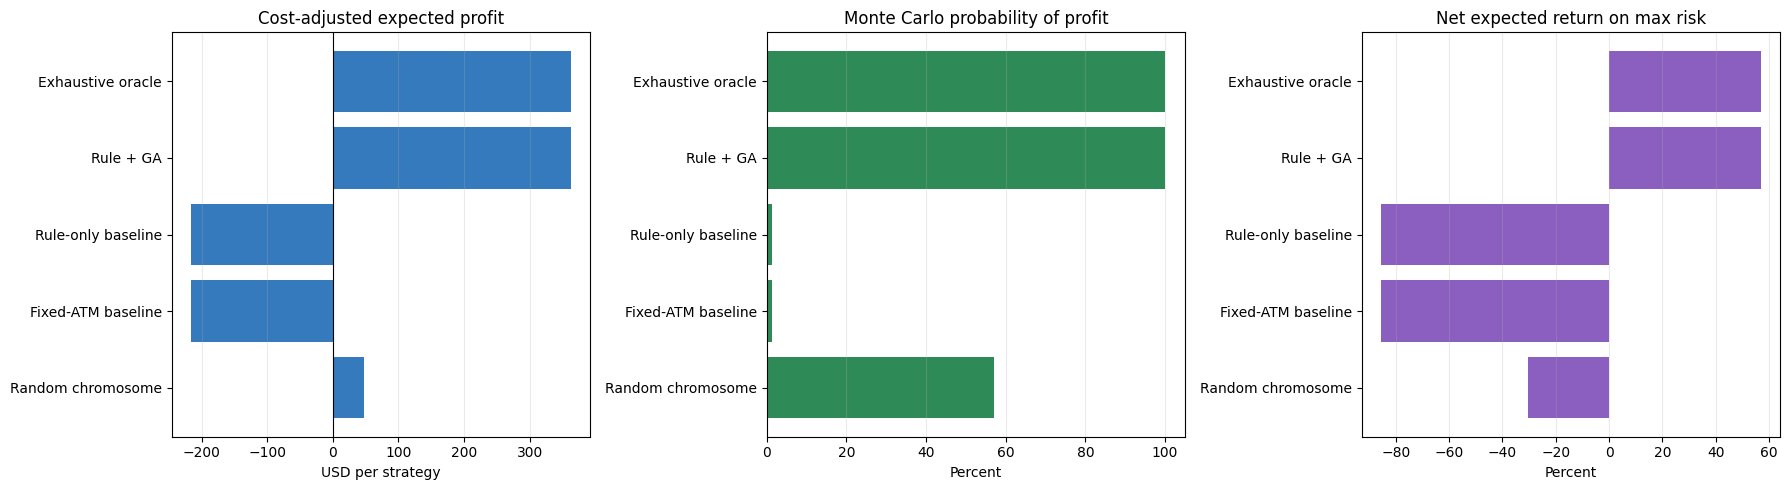

In [17]:
comparison_plot = method_comparison.copy()
comparison_plot["probability_of_profit_pct"] = comparison_plot["probability_of_profit"] * 100
comparison_plot["return_on_risk_pct"] = comparison_plot["net_expected_return_on_risk"] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(comparison_plot["method"], comparison_plot["adjusted_expected_profit"], color="#357ABD")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Cost-adjusted expected profit")
axes[0].set_xlabel("USD per strategy")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(comparison_plot["method"], comparison_plot["probability_of_profit_pct"], color="#2E8B57")
axes[1].set_title("Monte Carlo probability of profit")
axes[1].set_xlabel("Percent")
axes[1].grid(axis="x", alpha=0.25)

axes[2].barh(comparison_plot["method"], comparison_plot["return_on_risk_pct"], color="#8A5FBF")
axes[2].set_title("Net expected return on max risk")
axes[2].set_xlabel("Percent")
axes[2].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Historical-underlying stress simulation

Daily underlying returns are sampled in contiguous blocks equal to each candidate's DTE. Those returns create terminal stock prices, which are passed through today's expiration payoff and premium assumptions.

This preserves historical return patterns but **is not a historical option trade backtest**: strikes, premiums, liquidity, and Greeks are from the present candidate set.

In [19]:
close_column = "Close" if "Close" in history_features.columns else "close"
if close_column not in history_features.columns:
    raise KeyError("Notebook 1 history output must contain a Close column.")
close_prices = pd.to_numeric(history_features[close_column], errors="coerce").dropna()
historical_log_returns = np.log(close_prices / close_prices.shift(1)).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
if len(historical_log_returns) < 60:
    raise ValueError("At least 60 valid daily underlying returns are required for historical stress simulation.")

stress_rng = np.random.default_rng(RULE_RANDOM_SEED)
terminal_price_cache: dict[int, np.ndarray] = {}

def historical_terminal_prices(dte: int) -> np.ndarray:
    dte = max(1, int(dte))
    if dte not in terminal_price_cache:
        if len(historical_log_returns) >= dte:
            starts = stress_rng.integers(0, len(historical_log_returns) - dte + 1, size=HISTORICAL_STRESS_PATHS)
            cumulative_returns = np.array([
                historical_log_returns[start:start + dte].sum() for start in starts
            ])
        else:
            draws = stress_rng.choice(historical_log_returns, size=(HISTORICAL_STRESS_PATHS, dte), replace=True)
            cumulative_returns = draws.sum(axis=1)
        terminal_price_cache[dte] = spot_price * np.exp(cumulative_returns)
    return terminal_price_cache[dte]

def intrinsic_value(stock_prices: np.ndarray, strike: float, option_type: str) -> np.ndarray:
    return np.maximum(stock_prices - strike, 0) if option_type == "call" else np.maximum(strike - stock_prices, 0)

def stress_candidate(row: pd.Series) -> dict[str, float]:
    terminal_prices = historical_terminal_prices(int(row["dte"]))
    payoff_per_share = intrinsic_value(terminal_prices, float(row["long_strike"]), str(row["option_type"]))
    if int(row["short_strike_index"]) >= 0:
        payoff_per_share -= intrinsic_value(terminal_prices, float(row["short_strike"]), str(row["option_type"]))
    pnl = payoff_per_share * 100 + float(row["entry_cashflow_per_share"]) * 100 - float(row["estimated_transaction_cost"])
    return {
        "stress_expected_profit": float(pnl.mean()),
        "stress_probability_of_profit": float(np.mean(pnl > 0)),
        "stress_median_profit": float(np.median(pnl)),
        "stress_p05_profit": float(np.quantile(pnl, 0.05)),
        "stress_p95_profit": float(np.quantile(pnl, 0.95)),
    }

random_stress_source = random_rows.drop_duplicates("candidate_id").head(HISTORICAL_STRESS_RANDOM_CANDIDATES)
random_stress_metrics = pd.DataFrame([stress_candidate(row) for _, row in random_stress_source.iterrows()]).mean().to_dict()

historical_stress_rows = [{
    "method": "Random chromosome",
    "candidate_id": "aggregate of valid random candidates",
    **{key: float(value) for key, value in random_stress_metrics.items()},
}]
for method, row in selected_candidates.items():
    historical_stress_rows.append({"method": method, "candidate_id": row["candidate_id"], **stress_candidate(row)})

historical_stress_results = pd.DataFrame(historical_stress_rows)
method_comparison = method_comparison.merge(historical_stress_results.drop(columns="candidate_id"), on="method", how="left", validate="one_to_one")
display(historical_stress_results)

,method,candidate_id,stress_expected_profit,stress_probability_of_profit,stress_median_profit,stress_p05_profit,stress_p95_profit
0,Random chromosome,aggregate of valid random candidates,-85.5500,0.5005,17.7645,"-1,163.0872",800.0320
1,Fixed-ATM baseline,bull_call_spread|2026-10-02|L0|S1,-133.3161,0.2362,-252.8200,-252.8200,247.1800
2,Rule-only baseline,bull_call_spread|2026-10-02|L0|S1,-133.3161,0.2362,-252.8200,-252.8200,247.1800
3,Rule + GA,bull_put_spread|2026-10-02|L6|S7,-15.3673,0.5831,362.9800,-637.0200,362.9800
4,Exhaustive oracle,bull_put_spread|2026-10-02|L6|S7,-15.3673,0.5831,362.9800,-637.0200,362.9800


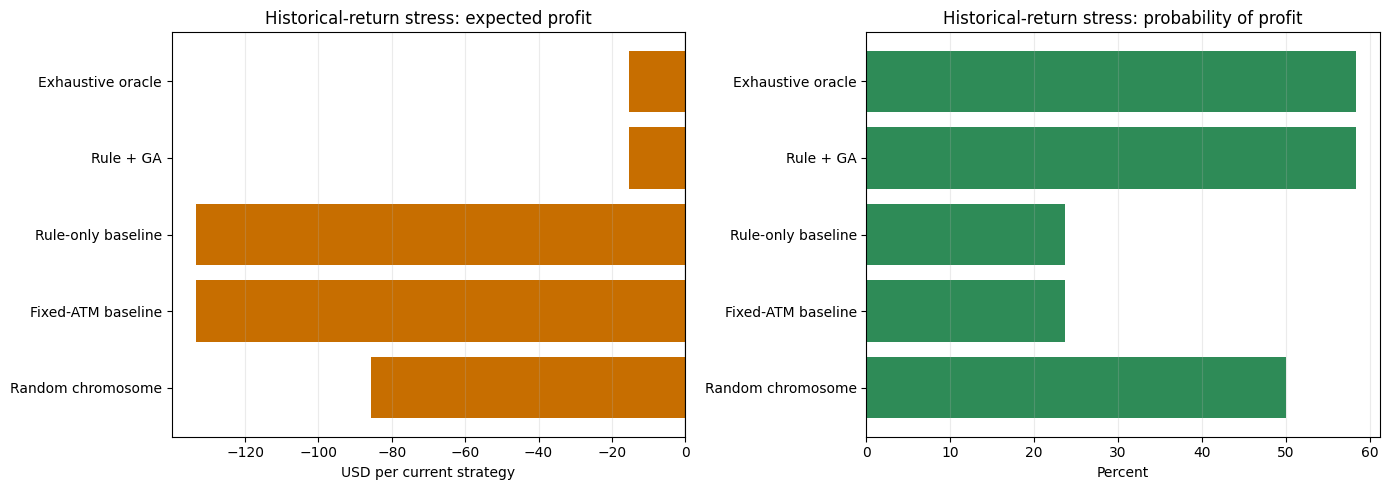

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(historical_stress_results["method"], historical_stress_results["stress_expected_profit"], color="#C76E00")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Historical-return stress: expected profit")
axes[0].set_xlabel("USD per current strategy")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(historical_stress_results["method"], historical_stress_results["stress_probability_of_profit"] * 100, color="#2E8B57")
axes[1].set_title("Historical-return stress: probability of profit")
axes[1].set_xlabel("Percent")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 7. GA convergence, repeated seeds, and cost sensitivity

,metric,value
0,Candidate universe,64.0000
1,GA generations,60.0000
2,Repeated seeds,10.0000
3,Oracle hit rate,1.0000
4,Mean optimality gap,0.0000
5,Worst optimality gap,0.0000
6,Cost scenarios,3.0000
7,Unique cost-sensitive recommendations,1.0000


,method,candidate_id,fitness_score,gap_to_oracle,improvement_vs_rule_baseline
0,Random feasible candidate (mean),NaN,49.2334,37.6553,26.2573
1,Notebook 4 rule/payoff baseline,bull_call_spread|2026-10-02|L0|S1,22.9761,63.9126,0.0000
2,Genetic algorithm,bull_put_spread|2026-10-02|L6|S7,86.8887,0.0000,63.9126
3,Exhaustive oracle,bull_put_spread|2026-10-02|L6|S7,86.8887,0.0000,63.9126


,cost_multiplier,candidate_id,strategy_type,fitness_score,estimated_transaction_cost,adjusted_expected_profit,net_expected_return_on_risk
0,0.0000,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.9016,0.0000,380.0000,0.6129
1,1.0000,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,17.0200,362.9800,0.5698
2,2.0000,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8757,34.0400,345.9600,0.5290


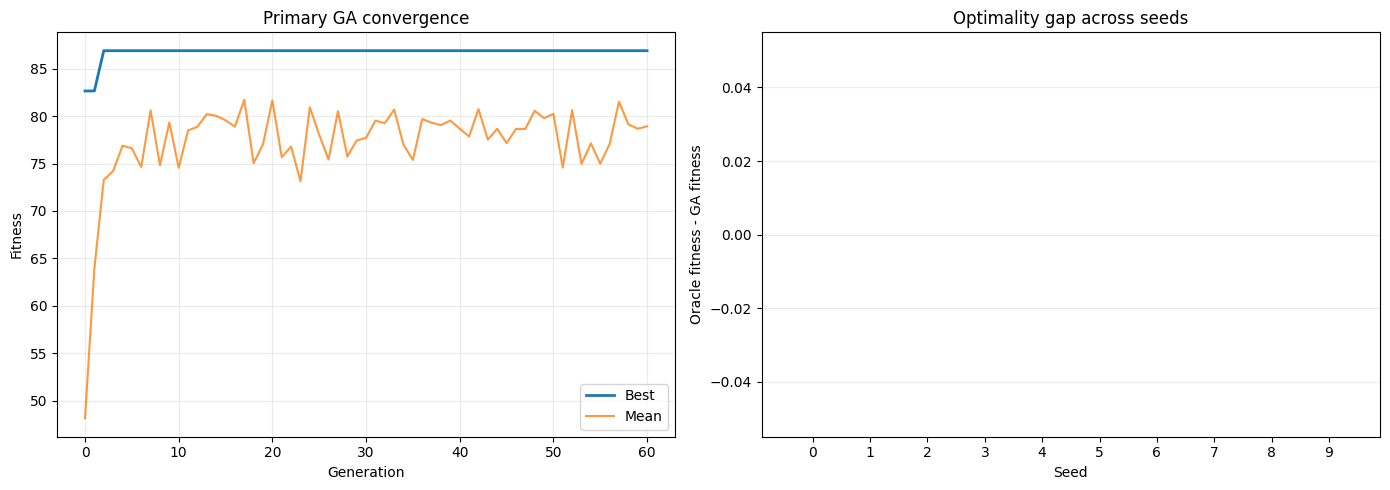

In [22]:
convergence_history["generation"] = pd.to_numeric(convergence_history["generation"], errors="coerce")
convergence_history["best_fitness"] = pd.to_numeric(convergence_history["best_fitness"], errors="coerce")
convergence_history["mean_fitness"] = pd.to_numeric(convergence_history["mean_fitness"], errors="coerce")
ga_run_summary["optimality_gap"] = pd.to_numeric(ga_run_summary["optimality_gap"], errors="coerce")
ga_run_summary["reached_oracle"] = normalise_passed(ga_run_summary["reached_oracle"])

ga_experiment_summary = pd.DataFrame([
    ("Candidate universe", len(ranked_recommendations)),
    ("GA generations", int(convergence_history["generation"].max())),
    ("Repeated seeds", ga_run_summary["seed"].nunique()),
    ("Oracle hit rate", ga_run_summary["reached_oracle"].mean()),
    ("Mean optimality gap", ga_run_summary["optimality_gap"].mean()),
    ("Worst optimality gap", ga_run_summary["optimality_gap"].max()),
    ("Cost scenarios", len(cost_sensitivity)),
    ("Unique cost-sensitive recommendations", cost_sensitivity["candidate_id"].nunique()),
], columns=["metric", "value"])
display(ga_experiment_summary)
display(ga_benchmark)
display(cost_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(convergence_history["generation"], convergence_history["best_fitness"], label="Best", linewidth=2)
axes[0].plot(convergence_history["generation"], convergence_history["mean_fitness"], label="Mean", alpha=0.8)
axes[0].set_title("Primary GA convergence")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Fitness")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].bar(ga_run_summary["seed"].astype(str), ga_run_summary["optimality_gap"], color="#8A5FBF")
axes[1].set_title("Optimality gap across seeds")
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("Oracle fitness - GA fitness")
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Fitness-weight sensitivity

Notebook 5 uses a balanced policy. Three alternative policies test whether the best result is excessively dependent on that single subjective weighting choice.

In [24]:
FITNESS_PROFILES = {
    "Balanced (Notebook 5)": {
        "net_expectancy": 0.30, "probability_of_profit": 0.20, "downside_protection": 0.15,
        "capital_efficiency": 0.10, "liquidity": 0.15, "reasoning_alignment": 0.10,
    },
    "Return focused": {
        "net_expectancy": 0.45, "probability_of_profit": 0.15, "downside_protection": 0.10,
        "capital_efficiency": 0.05, "liquidity": 0.15, "reasoning_alignment": 0.10,
    },
    "Conservative": {
        "net_expectancy": 0.20, "probability_of_profit": 0.25, "downside_protection": 0.25,
        "capital_efficiency": 0.15, "liquidity": 0.10, "reasoning_alignment": 0.05,
    },
    "Liquidity focused": {
        "net_expectancy": 0.20, "probability_of_profit": 0.15, "downside_protection": 0.10,
        "capital_efficiency": 0.10, "liquidity": 0.35, "reasoning_alignment": 0.10,
    },
}

component_names = list(next(iter(FITNESS_PROFILES.values())))
component_columns = [f"component_{name}" for name in component_names]
missing_components = sorted(set(component_columns) - set(ranked_recommendations.columns))
if missing_components:
    raise KeyError(f"Notebook 5 ranked recommendations are missing fitness components: {missing_components}")

balanced_scores = ranked_recommendations.set_index("candidate_id")["fitness_score"]
balanced_top_ids = set(balanced_scores.nlargest(TOP_K_SENSITIVITY).index)
weight_rows: list[dict[str, Any]] = []
for profile_name, weights in FITNESS_PROFILES.items():
    if not math.isclose(sum(weights.values()), 1.0, abs_tol=1e-9):
        raise ValueError(f"Fitness profile '{profile_name}' does not sum to 1.0.")
    profile_scores = 100 * sum(
        weights[name] * ranked_recommendations[f"component_{name}"] for name in component_names
    )
    best_index = int(profile_scores.idxmax())
    best = ranked_recommendations.loc[best_index]
    top_ids = set(ranked_recommendations.loc[profile_scores.nlargest(TOP_K_SENSITIVITY).index, "candidate_id"])
    weight_rows.append({
        "profile": profile_name,
        "candidate_id": best["candidate_id"],
        "strategy_type": best["strategy_type"],
        "profile_fitness_score": float(profile_scores.loc[best_index]),
        "adjusted_expected_profit": float(best["adjusted_expected_profit"]),
        "probability_of_profit": float(best["probability_of_profit"]),
        "adjusted_max_loss": float(best["adjusted_max_loss"]),
        "liquidity_score": float(best["liquidity_score"]),
        "top_k_overlap_with_balanced": len(top_ids & balanced_top_ids) / max(1, len(top_ids | balanced_top_ids)),
    })

fitness_weight_sensitivity = pd.DataFrame(weight_rows)
display(fitness_weight_sensitivity)

,profile,candidate_id,strategy_type,profile_fitness_score,adjusted_expected_profit,probability_of_profit,adjusted_max_loss,liquidity_score,top_k_overlap_with_balanced
0,Balanced (Notebook 5),bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,362.9800,1.0000,637.0200,56.8421,1.0000
1,Return focused,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,87.4646,362.9800,1.0000,637.0200,56.8421,0.8182
2,Conservative,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,91.9659,362.9800,1.0000,637.0200,56.8421,0.8182
3,Liquidity focused,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,84.2761,362.9800,1.0000,637.0200,56.8421,0.5385


## 9. Optional active-contract history validation

To use this check, save an active contract's `Date`, `Close`, and optional `Volume` history as the configured CSV. This confirms that an observable price path exists; it still cannot establish an expiration payoff until the contract expires.

In [26]:
if ACTIVE_CONTRACT_HISTORY_CSV.exists():
    active_history = pd.read_csv(ACTIVE_CONTRACT_HISTORY_CSV)
    if "Close" not in active_history.columns:
        raise KeyError("Active contract history CSV exists but has no Close column.")
    active_close = pd.to_numeric(active_history["Close"], errors="coerce")
    active_contract_validation = pd.DataFrame([{
        "available": True,
        "path": str(ACTIVE_CONTRACT_HISTORY_CSV),
        "rows": len(active_history),
        "non_missing_close_rate": float(active_close.notna().mean()),
        "non_negative_close_rate": float(active_close.dropna().ge(0).mean()) if active_close.notna().any() else 0.0,
        "date_start": active_history["Date"].iloc[0] if "Date" in active_history.columns and len(active_history) else None,
        "date_end": active_history["Date"].iloc[-1] if "Date" in active_history.columns and len(active_history) else None,
        "status": "Active price path available for inspection; not an expired-contract payoff backtest.",
    }])
else:
    active_contract_validation = pd.DataFrame([{
        "available": False,
        "path": str(ACTIVE_CONTRACT_HISTORY_CSV),
        "rows": 0,
        "non_missing_close_rate": np.nan,
        "non_negative_close_rate": np.nan,
        "date_start": None,
        "date_end": None,
        "status": "Optional active-contract history was not supplied; core evaluation is unaffected.",
    }])
display(active_contract_validation)

,available,path,rows,non_missing_close_rate,non_negative_close_rate,date_start,date_end,status
0,False,outputs\notebook_01\CRM\active_contract_history.csv,0,NaN,NaN,None,None,Optional active-contract history was not supplied; core evaluation is unaffected.


## 10. Findings and limitations

In [28]:
ga_method = method_comparison.loc[method_comparison["method"].eq("Rule + GA")].iloc[0]
rule_method = method_comparison.loc[method_comparison["method"].eq("Rule-only baseline")].iloc[0]
oracle_method = method_comparison.loc[method_comparison["method"].eq("Exhaustive oracle")].iloc[0]

experiment_findings = pd.DataFrame([
    {
        "finding": "Rule scenario pass rate",
        "value": float(rule_scenario_results["scenario_passed"].mean()),
        "interpretation": "Share of controlled scenarios satisfying direction, volatility preference, and score-bound expectations.",
    },
    {
        "finding": "Pipeline quality pass rate",
        "value": float(pipeline_quality_audit["passed"].mean()),
        "interpretation": "Share of quality gates passed across Notebooks 1-5.",
    },
    {
        "finding": "GA expected-profit improvement over rule-only",
        "value": float(ga_method["adjusted_expected_profit"] - rule_method["adjusted_expected_profit"]),
        "interpretation": "Cost-adjusted USD improvement for the current candidate snapshot.",
    },
    {
        "finding": "GA fitness improvement over rule-only",
        "value": float(ga_method["fitness_score"] - rule_method["fitness_score"]),
        "interpretation": "Improvement in the documented six-component decision objective.",
    },
    {
        "finding": "GA gap to exhaustive oracle",
        "value": float(oracle_method["fitness_score"] - ga_method["fitness_score"]),
        "interpretation": "Zero means the primary GA run found the best candidate in the finite MVP universe.",
    },
    {
        "finding": "GA historical-return stress expected profit",
        "value": float(ga_method["stress_expected_profit"]),
        "interpretation": "Expected payoff when historical underlying return blocks are applied to today's strategy and premium.",
    },
    {
        "finding": "Weight-profile recommendation count",
        "value": int(fitness_weight_sensitivity["candidate_id"].nunique()),
        "interpretation": "Number of different best candidates across four documented fitness policies.",
    },
])
display(experiment_findings)

limitations = pd.DataFrame([
    ("Historical option data", "No dependable expired-chain bid/ask archive; this notebook does not claim a historical options backtest."),
    ("Pricing", "Current ask-for-buy and bid-for-sell assumptions may still differ from realised fills."),
    ("Monte Carlo model", "Geometric-Brownian terminal prices simplify volatility dynamics, jumps, skew, and event risk."),
    ("Historical stress", "Reuses current strikes and premiums with past underlying returns; it is a stress simulation, not a trade replay."),
    ("Exercise and assignment", "Early exercise, assignment, dividends, pin risk, and margin changes are excluded."),
    ("Costs", "Commission, fee, and slippage parameters are estimates and should be replaced with broker-specific values."),
    ("Single-position MVP", "Results evaluate one strategy of one contract; portfolio exposure and cross-position constraints are excluded."),
    ("User outlook", "Bullish/bearish input is treated as a user belief and is not itself predicted or guaranteed by the system."),
    ("Live-chain instability", "Contract availability, implied volatility, spreads, and volume can change between data retrieval and execution."),
], columns=["limitation", "impact"])
display(limitations)

,finding,value,interpretation
0,Rule scenario pass rate,1.0000,"Share of controlled scenarios satisfying direction, volatility preference, and score-bound expectations."
1,Pipeline quality pass rate,1.0000,Share of quality gates passed across Notebooks 1-5.
2,GA expected-profit improvement over rule-only,579.4145,Cost-adjusted USD improvement for the current candidate snapshot.
3,GA fitness improvement over rule-only,63.9126,Improvement in the documented six-component decision objective.
4,GA gap to exhaustive oracle,0.0000,Zero means the primary GA run found the best candidate in the finite MVP universe.
5,GA historical-return stress expected profit,-15.3673,Expected payoff when historical underlying return blocks are applied to today's strategy and premium.
6,Weight-profile recommendation count,1.0000,Number of different best candidates across four documented fitness policies.


,limitation,impact
0,Historical option data,No dependable expired-chain bid/ask archive; this notebook does not claim a historical options backtest.
1,Pricing,Current ask-for-buy and bid-for-sell assumptions may still differ from realised fills.
2,Monte Carlo model,"Geometric-Brownian terminal prices simplify volatility dynamics, jumps, skew, and event risk."
3,Historical stress,"Reuses current strikes and premiums with past underlying returns; it is a stress simulation, not a trade replay."
4,Exercise and assignment,"Early exercise, assignment, dividends, pin risk, and margin changes are excluded."
5,Costs,"Commission, fee, and slippage parameters are estimates and should be replaced with broker-specific values."
6,Single-position MVP,Results evaluate one strategy of one contract; portfolio exposure and cross-position constraints are excluded.
7,User outlook,Bullish/bearish input is treated as a user belief and is not itself predicted or guaranteed by the system.
8,Live-chain instability,"Contract availability, implied volatility, spreads, and volume can change between data retrieval and execution."


## 11. Final evaluation quality checks

In [30]:
expected_methods = {
    "Random chromosome", "Fixed-ATM baseline", "Rule-only baseline", "Rule + GA", "Exhaustive oracle"
}
ga_directional_strategies = (
    {"bull_call_spread", "bull_put_spread", "long_call"}
    if outlook == "bullish"
    else {"bear_put_spread", "bear_call_spread", "long_put"}
)
all_weight_profiles_valid = all(math.isclose(sum(weights.values()), 1.0, abs_tol=1e-9) for weights in FITNESS_PROFILES.values())

quality_checks = {
    "all_upstream_requests_match": (
    feature_snapshot.get("request") == {"ticker": ticker}
        and all(
            record == expected_request
            for record in pair_request_records
        )
    ),
    "all_upstream_quality_checks_pass": bool(pipeline_quality_audit["passed"].all()),
    "ninety_six_rule_scenarios_executed": len(rule_scenario_results) == 96,
    "all_rule_scenarios_pass": bool(rule_scenario_results["scenario_passed"].all()),
    "all_rule_branches_covered": bool(rule_branch_coverage["covered"].all()),
    "current_rule_replay_matches_notebook3": current_rule_replay_matches,
    "all_five_comparison_methods_present": set(method_comparison["method"]) == expected_methods,
    "random_validity_rate_is_bounded": 0 < random_valid_rate <= 1,
    "deterministic_methods_are_valid": bool(method_comparison.loc[~method_comparison["method"].eq("Random chromosome"), "valid_recommendation_rate"].eq(1).all()),
    "ga_recommendation_matches_outlook": str(ga_method["strategy_type"]) in ga_directional_strategies,
    "ga_candidate_matches_notebook5_json": str(ga_method["candidate_id"]) == str(best_strategy["candidate_id"]),
    "comparison_metrics_are_finite": bool(np.isfinite(method_comparison[["adjusted_expected_profit", "probability_of_profit", "net_expected_return_on_risk", "adjusted_max_loss", "fitness_score"]]).all().all()),
    "probabilities_are_bounded": bool(method_comparison["probability_of_profit"].between(0, 1).all() and historical_stress_results["stress_probability_of_profit"].between(0, 1).all()),
    "historical_stress_has_enough_returns": len(historical_log_returns) >= 60,
    "historical_stress_results_are_finite": bool(np.isfinite(historical_stress_results[["stress_expected_profit", "stress_probability_of_profit", "stress_p05_profit", "stress_p95_profit"]]).all().all()),
    "ga_best_fitness_is_monotonic": bool(convergence_history["best_fitness"].diff().fillna(0).ge(-1e-10).all()),
    "repeated_ga_runs_are_recorded": ga_run_summary["seed"].nunique() >= 5,
    "cost_sensitivity_has_three_scenarios": len(cost_sensitivity) >= 3,
    "all_fitness_profiles_sum_to_one": all_weight_profiles_valid,
    "four_weight_profiles_tested": len(fitness_weight_sensitivity) == 4,
    "no_full_historical_backtest_claim": True,
}
evaluation_quality_report = pd.DataFrame([{"check": name, "passed": bool(passed)} for name, passed in quality_checks.items()])
display(evaluation_quality_report)
failed = evaluation_quality_report.loc[~evaluation_quality_report["passed"], "check"].tolist()
if failed:
    raise AssertionError(f"Notebook 6 evaluation quality checks failed: {failed}")
print("All Notebook 6 evaluation quality checks passed.")

,check,passed
0,all_upstream_requests_match,True
1,all_upstream_quality_checks_pass,True
2,ninety_six_rule_scenarios_executed,True
3,all_rule_scenarios_pass,True
4,all_rule_branches_covered,True
5,current_rule_replay_matches_notebook3,True
6,all_five_comparison_methods_present,True
7,random_validity_rate_is_bounded,True
8,deterministic_methods_are_valid,True
9,ga_recommendation_matches_outlook,True


All Notebook 6 evaluation quality checks passed.


## 12. Export the experimental evidence

In [32]:
evaluation_summary = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": expected_request,
    "evaluation_type": "Current-chain quantitative evaluation with controlled rules and historical-underlying stress simulation",
    "full_historical_options_backtest_claimed": False,
    "candidate_count": int(len(ranked_recommendations)),
    "rule_scenario_count": int(len(rule_scenario_results)),
    "rule_scenario_pass_rate": float(rule_scenario_results["scenario_passed"].mean()),
    "rule_branch_coverage_rate": float(rule_branch_coverage["covered"].mean()),
    "pipeline_quality_pass_rate": float(pipeline_quality_audit["passed"].mean()),
    "random_chromosome_valid_rate": float(random_valid_rate),
    "ga_candidate_id": str(ga_method["candidate_id"]),
    "ga_strategy_type": str(ga_method["strategy_type"]),
    "ga_adjusted_expected_profit": float(ga_method["adjusted_expected_profit"]),
    "ga_probability_of_profit": float(ga_method["probability_of_profit"]),
    "ga_expected_profit_improvement_vs_rule_only": float(ga_method["expected_profit_improvement_vs_rule_only"]),
    "ga_fitness_improvement_vs_rule_only": float(ga_method["fitness_improvement_vs_rule_only"]),
    "ga_gap_to_exhaustive_oracle": float(oracle_method["fitness_score"] - ga_method["fitness_score"]),
    "ga_oracle_hit_rate_across_seeds": float(ga_run_summary["reached_oracle"].mean()),
    "ga_historical_stress_expected_profit": float(ga_method["stress_expected_profit"]),
    "ga_historical_stress_probability_of_profit": float(ga_method["stress_probability_of_profit"]),
    "fitness_weight_profile_count": int(len(fitness_weight_sensitivity)),
    "unique_weight_sensitive_recommendations": int(fitness_weight_sensitivity["candidate_id"].nunique()),
    "active_contract_history_available": bool(active_contract_validation["available"].iloc[0]),
}

export_paths = {
    "pipeline_quality_audit": OUTPUT_DIR / "pipeline_quality_audit.csv",
    "rule_scenarios": OUTPUT_DIR / "rule_scenario_results.csv",
    "rule_branch_coverage": OUTPUT_DIR / "rule_branch_coverage.csv",
    "method_comparison": OUTPUT_DIR / "method_comparison.csv",
    "historical_stress": OUTPUT_DIR / "historical_stress_results.csv",
    "weight_sensitivity": OUTPUT_DIR / "fitness_weight_sensitivity.csv",
    "ga_experiment_summary": OUTPUT_DIR / "ga_experiment_summary.csv",
    "active_contract_validation": OUTPUT_DIR / "active_contract_validation.csv",
    "findings": OUTPUT_DIR / "experiment_findings.csv",
    "limitations": OUTPUT_DIR / "evaluation_limitations.csv",
    "quality_report": OUTPUT_DIR / "evaluation_quality_report.csv",
    "evaluation_summary": OUTPUT_DIR / "evaluation_summary.json",
}

pipeline_quality_audit.to_csv(export_paths["pipeline_quality_audit"], index=False)
rule_scenario_results.to_csv(export_paths["rule_scenarios"], index=False)
rule_branch_coverage.to_csv(export_paths["rule_branch_coverage"], index=False)
method_comparison.to_csv(export_paths["method_comparison"], index=False)
historical_stress_results.to_csv(export_paths["historical_stress"], index=False)
fitness_weight_sensitivity.to_csv(export_paths["weight_sensitivity"], index=False)
ga_experiment_summary.to_csv(export_paths["ga_experiment_summary"], index=False)
active_contract_validation.to_csv(export_paths["active_contract_validation"], index=False)
experiment_findings.to_csv(export_paths["findings"], index=False)
limitations.to_csv(export_paths["limitations"], index=False)
evaluation_quality_report.to_csv(export_paths["quality_report"], index=False)
with export_paths["evaluation_summary"].open("w", encoding="utf-8") as file:
    json.dump(evaluation_summary, file, indent=2, allow_nan=False)

export_manifest = pd.DataFrame([{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in export_paths.items()])
display(export_manifest)
success_marker = OUTPUT_DIR / "_SUCCESS.json"
success_marker.write_text(json.dumps({
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": expected_request,
    "notebook": "06_Experiments_and_Evaluation.ipynb",
}, indent=2), encoding="utf-8")
print(f"Completion marker: {success_marker}")


,dataset,path,exists
0,pipeline_quality_audit,outputs\notebook_06\CRM\bullish\pipeline_quality_audit.csv,True
1,rule_scenarios,outputs\notebook_06\CRM\bullish\rule_scenario_results.csv,True
2,rule_branch_coverage,outputs\notebook_06\CRM\bullish\rule_branch_coverage.csv,True
3,method_comparison,outputs\notebook_06\CRM\bullish\method_comparison.csv,True
4,historical_stress,outputs\notebook_06\CRM\bullish\historical_stress_results.csv,True
5,weight_sensitivity,outputs\notebook_06\CRM\bullish\fitness_weight_sensitivity.csv,True
6,ga_experiment_summary,outputs\notebook_06\CRM\bullish\ga_experiment_summary.csv,True
7,active_contract_validation,outputs\notebook_06\CRM\bullish\active_contract_validation.csv,True
8,findings,outputs\notebook_06\CRM\bullish\experiment_findings.csv,True
9,limitations,outputs\notebook_06\CRM\bullish\evaluation_limitations.csv,True


Completion marker: outputs\notebook_06\CRM\bullish\_SUCCESS.json


## Notebook 6 completion criteria

Notebook 6 is complete when all evaluation checks pass and twelve evidence files are created. The results must include:

- complete upstream quality evidence;
- 96 controlled rule scenarios with every branch covered;
- random, fixed-ATM, rule-only, GA, and exhaustive comparisons;
- historical-underlying stress results clearly distinguished from backtesting;
- repeated-seed, cost, and fitness-weight sensitivity evidence;
- explicit findings, limitations, and a machine-readable evaluation summary.

The next stage is the end-to-end user interface or application demo that accepts only a ticker and bullish/bearish outlook and presents the recommendation with its explanation and risk metrics.